In [8]:
#HI-2454-Final Project
#Project title: Exploring Risk Factore and Characteristics Related to Alzheimer's Diagnosis
# Student: Dr Tarique Bagalkot

# Loading the data set file
from google.colab import files
uploaded = files.upload()


Saving alzheimers_disease_data.csv to alzheimers_disease_data.csv


In [9]:
# The shape and first few ros of the dataset
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind, chi2_contingency
import statsmodels.api as sm
import statsmodels.formula.api as smf
df = pd.read_csv('alzheimers_disease_data.csv')
df.shape, df.head()

((2149, 35),
    PatientID  Age  Gender  Ethnicity  EducationLevel        BMI  Smoking  \
 0       4751   73       0          0               2  22.927749        0   
 1       4752   89       0          0               0  26.827681        0   
 2       4753   73       0          3               1  17.795882        0   
 3       4754   74       1          0               1  33.800817        1   
 4       4755   89       0          0               0  20.716974        0   
 
    AlcoholConsumption  PhysicalActivity  DietQuality  ...  MemoryComplaints  \
 0           13.297218          6.327112     1.347214  ...                 0   
 1            4.542524          7.619885     0.518767  ...                 0   
 2           19.555085          7.844988     1.826335  ...                 0   
 3           12.209266          8.428001     7.435604  ...                 0   
 4           18.454356          6.310461     0.795498  ...                 0   
 
    BehavioralProblems       ADL  Confusi

In [10]:
# Dropping irrelevant columns
df_cleaned = df.drop(columns=["PatientID", "DoctorInCharge"])

# Dropping rows with missing values
df_cleaned = df_cleaned.dropna()

# Checking for missing values
missing_values = df_cleaned.isnull().sum()
missing_summary = missing_values[missing_values > 0]
print("\nMissing Values Summary:")
print(missing_summary)

# Normalizing BMI and MMSE using Min-Max scaling
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_cleaned[['BMI', 'MMSE']] = scaler.fit_transform(df_cleaned[['BMI', 'MMSE']])

# Convert Diagnosis to integer (Target)
df_cleaned['Diagnosis'] = df_cleaned['Diagnosis'].astype(int)

# Diagnosis distribution
diagnosis_distribution = df_cleaned['Diagnosis'].value_counts(normalize=True)
print("\nDiagnosis Distribution (Proportion):")
print(diagnosis_distribution)




Missing Values Summary:
Series([], dtype: int64)

Diagnosis Distribution (Proportion):
Diagnosis
0    0.646347
1    0.353653
Name: proportion, dtype: float64


In [12]:
# EXPLORATORY
summary_stats = df_cleaned.describe()
print("\nSummary Statistics (mean, std, min, max):")
print(summary_stats.T[['mean', 'std', 'min', 'max']])




Summary Statistics (mean, std, min, max):
                                 mean         std         min         max
Age                         74.908795    8.990221   60.000000   90.000000
Gender                       0.506282    0.500077    0.000000    1.000000
Ethnicity                    0.697534    0.996128    0.000000    3.000000
EducationLevel               1.286645    0.904527    0.000000    3.000000
BMI                          0.506199    0.288883    0.000000    1.000000
Smoking                      0.288506    0.453173    0.000000    1.000000
AlcoholConsumption          10.039442    5.757910    0.002003   19.989293
PhysicalActivity             4.920202    2.857191    0.003616    9.987429
DietQuality                  4.993138    2.909055    0.009385    9.998346
SleepQuality                 7.051081    1.763573    4.002629    9.999840
FamilyHistoryAlzheimers      0.252210    0.434382    0.000000    1.000000
CardiovascularDisease        0.144253    0.351428    0.000000    1.00

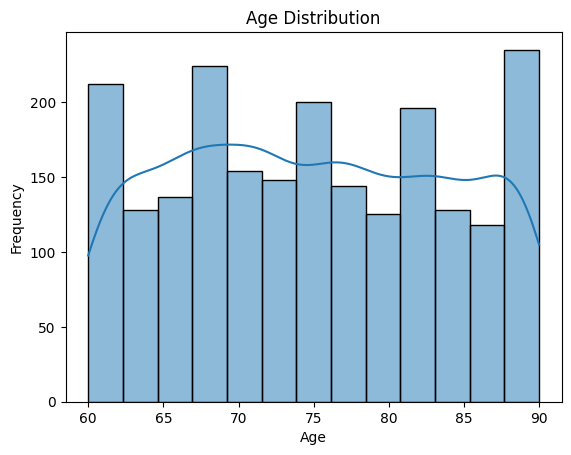

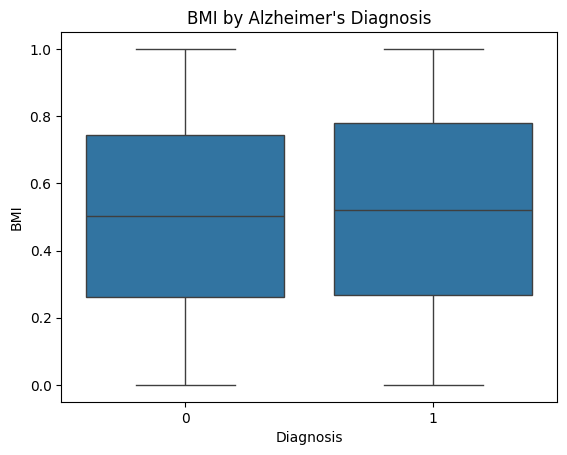

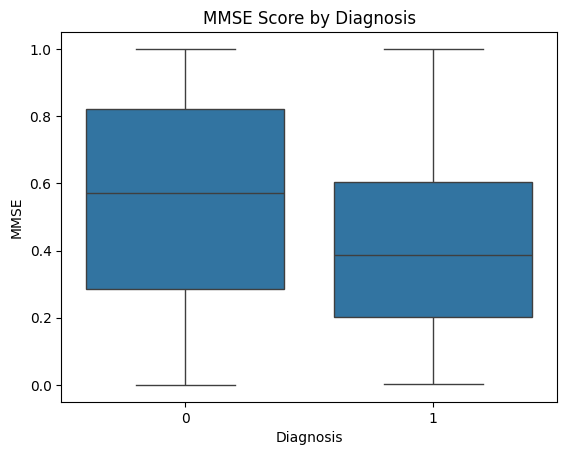

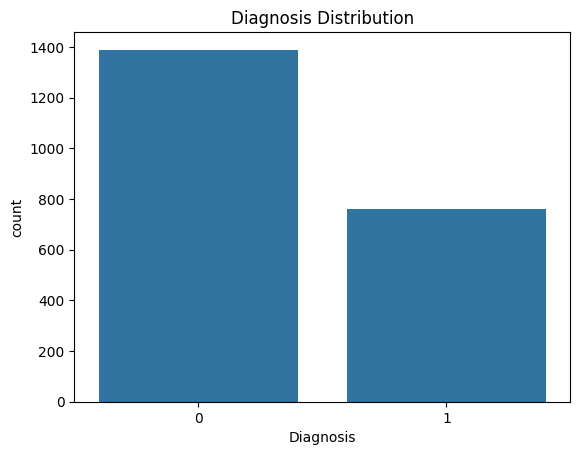

In [15]:
#VISUALIZATION

#VISUALIZATION

import seaborn as sns
import matplotlib.pyplot as plt

# Distribution of Age
sns.histplot(df_cleaned['Age'], kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# Boxplot: BMI by Diagnosis
sns.boxplot(x='Diagnosis', y='BMI', data=df_cleaned)
plt.title("BMI by Alzheimer's Diagnosis")
plt.show()

# Boxplot: MMSE by Diagnosis
sns.boxplot(x='Diagnosis', y='MMSE', data=df_cleaned)
plt.title("MMSE Score by Diagnosis")
plt.show()

# Bar chart: Diagnosis counts
sns.countplot(x='Diagnosis', data=df_cleaned)
plt.title("Diagnosis Distribution")
plt.show()



In [27]:
# T-Test
diagnosis_distribution = df_cleaned['Diagnosis'].value_counts(normalize=True)
df_ad = df_cleaned[df_cleaned['Diagnosis'] == 1]
df_nonad = df_cleaned[df_cleaned['Diagnosis'] == 0]

from scipy.stats import ttest_ind
import pandas as pd

# Get numerical columns
numerical_cols = df_cleaned.select_dtypes(include='number').columns.drop('Diagnosis')

#T-tests
ttest_results = {}
for col in numerical_cols:
    stat, pval = ttest_ind(df_ad[col].dropna(), df_nonad[col].dropna(), equal_var=False)
    ttest_results[col] = pval

# Show sorted p-values
print("\nT-test p-values:")
print(pd.Series(ttest_results).sort_values())
print("\nSignificant results (p < 0.05):")
significant = {k: v for k, v in ttest_results.items() if v < 0.05}
print(pd.Series(significant).sort_values())





T-test p-values:
FunctionalAssessment         5.715771e-70
ADL                          6.022317e-57
MemoryComplaints             1.249794e-37
MMSE                         4.004561e-32
BehavioralProblems           9.316950e-21
SleepQuality                 8.668774e-03
EducationLevel               4.143049e-02
CholesterolHDL               4.894983e-02
Hypertension                 1.113241e-01
FamilyHistoryAlzheimers      1.229514e-01
Diabetes                     1.366379e-01
CholesterolLDL               1.379348e-01
CardiovascularDisease        1.522833e-01
BMI                          2.246463e-01
Disorientation               2.466319e-01
CholesterolTriglycerides     2.938012e-01
HeadInjury                   3.120863e-01
Gender                       3.312356e-01
PersonalityChanges           3.331877e-01
Confusion                    3.699276e-01
SystolicBP                   4.694831e-01
Ethnicity                    4.911669e-01
DifficultyCompletingTasks    6.759888e-01
DietQuality     

In [34]:
# Assuming categorical variables are encoded (0/1 or discrete integers)
categorical_cols = ['Gender', 'Smoking', 'FamilyHistoryAlzheimers', 'Depression']

chi2_results = {}
for col in categorical_cols:
    contingency = pd.crosstab(df[col], df['Diagnosis'])
    _, pval, _, _ = chi2_contingency(contingency)
    chi2_results[col] = pval

print("\nChi-square p-values:")
print(pd.Series(chi2_results).sort_values())


Chi-square p-values:
FamilyHistoryAlzheimers    0.140698
Gender                     0.353818
Depression                 0.828334
Smoking                    0.860493
dtype: float64


Optimization terminated successfully.
         Current function value: 0.619228
         Iterations 5
                            Coef.         P>|z|
Intercept                0.410970  3.791761e-01
Age                     -0.002028  6.962252e-01
Gender                  -0.065720  4.810271e-01
EducationLevel          -0.090264  8.065855e-02
BMI                      0.007611  2.382383e-01
Smoking                 -0.032796  7.506395e-01
AlcoholConsumption      -0.004198  6.039969e-01
PhysicalActivity         0.001610  9.214616e-01
MMSE                    -0.059793  9.160395e-27
FamilyHistoryAlzheimers -0.148855  1.708341e-01
Depression              -0.004689  9.679469e-01


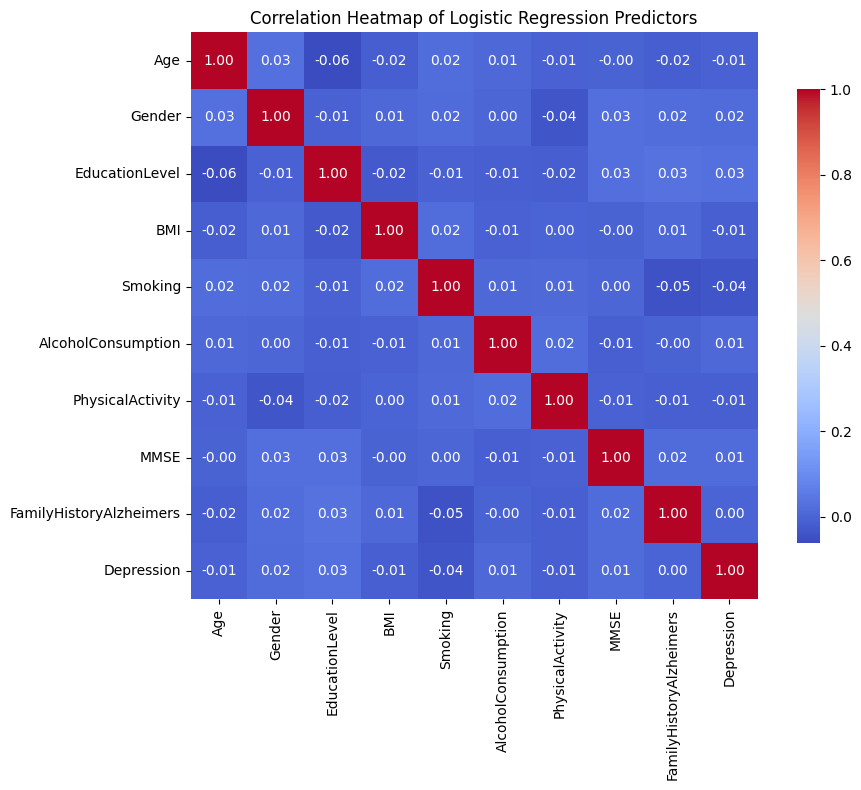

In [16]:
# Define predictors
predictors = [
    'Age', 'Gender', 'EducationLevel', 'BMI', 'Smoking',
    'AlcoholConsumption', 'PhysicalActivity', 'MMSE',
    'FamilyHistoryAlzheimers', 'Depression'
]

# Create formula for statsmodels
formula = 'Diagnosis ~ ' + ' + '.join(predictors)

# Fit logistic regression
logit_model = smf.logit(formula=formula, data=df).fit()

# Show summary of coefficients and p-values
print(logit_model.summary2().tables[1][['Coef.', 'P>|z|']])

# Calculate correlation matrix for logistic regression predictors
correlation_matrix = df_cleaned[[
    'Age', 'Gender', 'EducationLevel', 'BMI', 'Smoking',
    'AlcoholConsumption', 'PhysicalActivity', 'MMSE',
    'FamilyHistoryAlzheimers', 'Depression'
]].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={'shrink': 0.8})
plt.title("Correlation Heatmap of Logistic Regression Predictors")
plt.tight_layout()
plt.show()